In [66]:
import pandas as pd

# Carichiamo l'anagrafica
df_patients = pd.read_csv('patients.csv')

# Visualizziamo tutte le colonne disponibili e le prime 5 righe
pd.set_option('display.max_columns', None)
print(df_patients.head())

                                     Id   BIRTHDATE DEATHDATE          SSN  \
0  b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85  2019-02-17       NaN  999-65-3251   
1  c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8  2005-07-04       NaN  999-49-3323   
2  339144f8-50e1-633e-a013-f361391c4cff  1998-05-11       NaN  999-10-8743   
3  d488232e-bf14-4bed-08c0-a82f34b6a197  2003-01-28       NaN  999-56-6057   
4  217f95a3-4e10-bd5d-fb67-0cfb5e8ba075  1993-12-23       NaN  999-91-4320   

     DRIVERS    PASSPORT PREFIX       FIRST            LAST SUFFIX MAIDEN  \
0        NaN         NaN    NaN    Damon455      Langosh790    NaN    NaN   
1  S99941126         NaN    NaN       Thi53       Wunsch504    NaN    NaN   
2  S99996708  X75063318X    Mr.      Chi716  Greenfelder433    NaN    NaN   
3  S99929424         NaN    Ms.  Phillis443       Walter473    NaN    NaN   
4  S99991143  X44132498X    Mr.  Jerrold404       Herzog843    NaN    NaN   

  MARITAL   RACE    ETHNICITY GENDER                        BIRTHPLA

In [67]:
import pandas as pd
import hashlib
import datetime

def pipeline_anonimizzazione(df_raw, fascia_eta=20, cifre_cap=2):
    
    df = df_raw.copy()
    
    # 1. HASHING (Identificatori diretti)
    def hash_ssn(ssn):
        if pd.isna(ssn): return ssn
        return hashlib.sha256(str(ssn).encode('utf-8')).hexdigest()
    
    df['SSN_HASHED'] = df['SSN'].apply(hash_ssn)
    
    # 2. MASKING (Identificatori diretti testuali)
    def mask_string(testo):
        if pd.isna(testo): return testo
        return str(testo)[0] + "***" if len(str(testo)) > 0 else testo

    df['FIRST_MASKED'] = df['FIRST'].apply(mask_string)
    df['LAST_MASKED'] = df['LAST'].apply(mask_string)
    
    # 3. SOPPRESSIONE (Rimozione colonne in chiaro sensibili/inutili)
    colonne_da_rimuovere = ['SSN', 'FIRST', 'LAST', 'ADDRESS', 'DRIVERS', 
                            'PASSPORT', 'PREFIX', 'SUFFIX', 'MAIDEN', 'LAT', 'LON']
    df = df.drop(columns=[col for col in colonne_da_rimuovere if col in df.columns])
    
    # 4. GENERALIZZAZIONE ETÀ
    df['BIRTHDATE'] = pd.to_datetime(df['BIRTHDATE'], errors='coerce')
    anno_corrente = datetime.datetime.now().year
    df['AGE'] = anno_corrente - df['BIRTHDATE'].dt.year
    
    def generalizza_eta(eta):
        if pd.isna(eta): return "Sconosciuta"
        ventennio = int((eta // fascia_eta) * fascia_eta)
        return f"{ventennio}-{ventennio + (fascia_eta - 1)}"
        
    df['AGE_GROUP'] = df['AGE'].apply(generalizza_eta)
    
    # 5. GENERALIZZAZIONE CAP (ZIP Code)
    def generalizza_cap(zip_code):
        if pd.isna(zip_code): return "00000"[:cifre_cap] + "*" * (5 - cifre_cap)
        zip_str = str(int(zip_code)).zfill(5)
        return zip_str[:cifre_cap] + "*" * (5 - cifre_cap)

    df['ZIP_GROUP'] = df['ZIP'].apply(generalizza_cap)
    
    return df

In [68]:
def report_k_anonymity(df_anonimizzato):
    
    quasi_identifiers = ['AGE_GROUP', 'GENDER', 'ZIP_GROUP']
    
    # Raggruppamento per classi di equivalenza
    k_anon_counts = df_anonimizzato.groupby(quasi_identifiers).size().reset_index(name='Count')
    k_anon_counts = k_anon_counts.sort_values(by='Count')
    
    k_minimo = k_anon_counts['Count'].min()
    
    print("=== REPORT K-ANONYMITY ===")
    print(f"Livello k minimo raggiunto dal dataset: k = {k_minimo}")
    print("\nLe 10 classi di equivalenza più piccole (a maggior rischio):")
    print(k_anon_counts.head(10).to_string(index=False))
    
    return k_minimo, k_anon_counts

In [69]:
# Caricamento dati grezzi
df_patients_raw = pd.read_csv('patients.csv')

# Esecuzione della pipeline (es. fasce di 20 anni, 2 cifre per il CAP)
df_protetto = pipeline_anonimizzazione(df_patients_raw, fascia_eta=20, cifre_cap=2)

# Generazione del report
k_val, classi_rischio = report_k_anonymity(df_protetto)

=== REPORT K-ANONYMITY ===
Livello k minimo raggiunto dal dataset: k = 5

Le 10 classi di equivalenza più piccole (a maggior rischio):
AGE_GROUP GENDER ZIP_GROUP  Count
  100-119      F     01***      5
    80-99      M     01***      6
    80-99      F     02***      8
  100-119      M     02***      9
  100-119      M     01***      9
  100-119      F     02***      9
    80-99      M     02***     14
     0-19      F     01***     15
    80-99      F     01***     15
    80-99      F     00***     16


In [70]:
# 1. Carichiamo i dati sensibili: le condizioni mediche
df_conditions = pd.read_csv('conditions.csv')

# 2. Uniamo (Merge) i due dataset
# Usiamo direttamente 'df_protetto', il dataset sicuro generato dalla nostra pipeline!
df_merged = pd.merge(df_protetto, df_conditions, left_on='Id', right_on='PATIENT', how='inner')

# 3. IL TOCCO FINALE DI SICUREZZA: Rimuoviamo gli ID di sistema in chiaro!
colonne_da_rimuovere_finali = ['Id', 'PATIENT']
df_final_secure = df_merged.drop(columns=colonne_da_rimuovere_finali)

# 4. VALUTAZIONE UTILITÀ: Testiamo una query tipica
# Domanda: Quali sono le 5 malattie più comuni nelle donne tra i 20 e i 39 anni?
query_donne_giovani = df_final_secure[
    (df_final_secure['GENDER'] == 'F') & 
    (df_final_secure['AGE_GROUP'] == '20-39')
]

top_malattie = query_donne_giovani['DESCRIPTION'].value_counts().head(5)

print("=== TOP 5 DIAGNOSI (DONNE 20-39 ANNI) NEL DATASET ANONIMO ===")
print(top_malattie)

=== TOP 5 DIAGNOSI (DONNE 20-39 ANNI) NEL DATASET ANONIMO ===
DESCRIPTION
Full-time employment (finding)    465
Normal pregnancy                  243
Stress (finding)                  215
Viral sinusitis (disorder)        173
Part-time employment (finding)    105
Name: count, dtype: int64


In [71]:
import numpy as np
import datetime
anno_corrente = datetime.datetime.now().year

# 1. Ricarichiamo i dati originali "in chiaro" come Ground Truth per fare il confronto
df_raw_patients = pd.read_csv('patients.csv')
df_raw_patients['BIRTHDATE'] = pd.to_datetime(df_raw_patients['BIRTHDATE'], errors='coerce')
df_raw_patients['AGE'] = anno_corrente - df_raw_patients['BIRTHDATE'].dt.year
df_raw_merged = pd.merge(df_raw_patients, df_conditions, left_on='Id', right_on='PATIENT', how='inner')

# Prepariamo il dataset anonimo calcolando il "Punto Medio" della fascia d'età per le stime
def get_midpoint(age_group):
    if age_group == "Sconosciuta": return np.nan
    try:
        parts = age_group.split('-')
        return (int(parts[0]) + int(parts[1])) / 2
    except:
        return np.nan

df_final_secure['AGE_MIDPOINT'] = df_final_secure['AGE_GROUP'].apply(get_midpoint)

print("=== VALUTAZIONE UTILITÀ: ERRORE RELATIVO SU 3 QUERY ===")

# --- QUERY 1: Età media dei pazienti con Sinusite Virale ---
malattia = "Viral sinusitis (disorder)"
vero_avg_eta = df_raw_merged[df_raw_merged['DESCRIPTION'] == malattia]['AGE'].mean()
anon_avg_eta = df_final_secure[df_final_secure['DESCRIPTION'] == malattia]['AGE_MIDPOINT'].mean()
err_rel_1 = abs(vero_avg_eta - anon_avg_eta) / vero_avg_eta
print(f"\n1. Età media per '{malattia}':")
print(f"   Valore Reale: {vero_avg_eta:.1f} anni | Stima Anonimizzata: {anon_avg_eta:.1f} anni")
print(f"   Errore Relativo: {err_rel_1:.2%}")

# --- QUERY 2: Numero di diagnosi per donne di *esattamente* 30 anni ---
vero_count_30F = len(df_raw_merged[(df_raw_merged['AGE'] == 30) & (df_raw_merged['GENDER'] == 'F')])
count_20_39_F = len(df_final_secure[(df_final_secure['AGE_GROUP'] == '20-39') & (df_final_secure['GENDER'] == 'F')])
stima_count_30F = count_20_39_F / 20
err_rel_2 = abs(vero_count_30F - stima_count_30F) / vero_count_30F if vero_count_30F > 0 else 0
print(f"\n2. Numero diagnosi (Donne, 30 anni esatti):")
print(f"   Valore Reale: {vero_count_30F} | Stima Anonimizzata: {stima_count_30F:.1f}")
print(f"   Errore Relativo: {err_rel_2:.2%}")

# --- QUERY 3: Casi di 'Stress' in una zona specifica ---
cap_frequente = df_raw_merged['ZIP'].value_counts().idxmax()
vero_stress_cap = len(df_raw_merged[(df_raw_merged['ZIP'] == cap_frequente) & (df_raw_merged['DESCRIPTION'] == 'Stress (finding)')])

cap_anonimo_target = str(int(cap_frequente)).zfill(5)[:2] + "***"
stress_area_anon = len(df_final_secure[(df_final_secure['ZIP_GROUP'] == cap_anonimo_target) & (df_final_secure['DESCRIPTION'] == 'Stress (finding)')])

num_cap_unici = df_raw_merged[df_raw_merged['ZIP'].astype(str).str.zfill(5).str.startswith(cap_anonimo_target[:2])]['ZIP'].nunique()
stima_stress_cap = stress_area_anon / num_cap_unici if num_cap_unici > 0 else 0
err_rel_3 = abs(vero_stress_cap - stima_stress_cap) / vero_stress_cap if vero_stress_cap > 0 else 0

print(f"\n3. Casi di 'Stress' nel CAP specifico {cap_frequente}:")
print(f"   Valore Reale: {vero_stress_cap} | Stima Anonimizzata: {stima_stress_cap:.1f}")
print(f"   Errore Relativo: {err_rel_3:.2%}")

=== VALUTAZIONE UTILITÀ: ERRORE RELATIVO SU 3 QUERY ===

1. Età media per 'Viral sinusitis (disorder)':
   Valore Reale: 53.8 anni | Stima Anonimizzata: 53.8 anni
   Errore Relativo: 0.09%

2. Numero diagnosi (Donne, 30 anni esatti):
   Valore Reale: 105 | Stima Anonimizzata: 137.2
   Errore Relativo: 30.71%

3. Casi di 'Stress' nel CAP specifico 2171.0:
   Valore Reale: 117 | Stima Anonimizzata: 0.0
   Errore Relativo: 100.00%


In [72]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt

# 1. Preparazione Ground Truth (dati non anonimizzati)
df_raw = pd.read_csv('patients.csv')
df_cond = pd.read_csv('conditions.csv')

# ---> CORREZIONE: Calcoliamo l'età (AGE) sui dati originali prima del merge
df_raw['BIRTHDATE'] = pd.to_datetime(df_raw['BIRTHDATE'], errors='coerce')
anno_corrente = datetime.datetime.now().year
df_raw['AGE'] = anno_corrente - df_raw['BIRTHDATE'].dt.year

# Ora possiamo unire i dataset
df_raw_merged = pd.merge(df_raw, df_cond, left_on='Id', right_on='PATIENT', how='inner')

# Funzione di supporto per trovare il punto medio della fascia d'età
def get_midpoint(age_group):
    if age_group == "Sconosciuta": return np.nan
    try:
        parts = age_group.split('-')
        return (int(parts[0]) + int(parts[1])) / 2
    except:
        return np.nan

# 2. Funzione di calcolo utilità
def report_utilita(df_raw, df_anon):
    print("=== REPORT UTILITÀ: ANALISI STATISTICA ===")
    
    # Query A: Confronto Media Età (Distribuzione)
    media_raw = df_raw_merged['AGE'].mean()
    # Usiamo il midpoint della fascia d'età per approssimare l'età nell'anonimo
    media_anon = df_anon['AGE_GROUP'].apply(get_midpoint).mean() 
    err_media = abs(media_raw - media_anon) / media_raw
    print(f"1. Media Età: Reale {media_raw:.1f} vs Anon {media_anon:.1f} (Errore: {err_media:.2%})")
    
    # Query B: Conteggio Diagnosi 'Normal pregnancy' (Conteggio)
    count_raw = len(df_raw_merged[df_raw_merged['DESCRIPTION'] == 'Normal pregnancy'])
    count_anon = len(df_anon[df_anon['DESCRIPTION'] == 'Normal pregnancy'])
    err_count = abs(count_raw - count_anon) / count_raw
    print(f"2. Conteggio 'Normal pregnancy': Reale {count_raw} vs Anon {count_anon} (Errore: {err_count:.2%})")
    
    # Query C: Confronto Distribuzione per Genere (Trend)
    dist_raw = df_raw_merged['GENDER'].value_counts(normalize=True)
    dist_anon = df_anon['GENDER'].value_counts(normalize=True)
    print("\n3. Confronto Distribuzione Genere (Trend):")
    print(f"Reale:\n{dist_raw.to_string()}")
    print(f"Anonimizzato:\n{dist_anon.to_string()}")

# Esecuzione
report_utilita(df_raw, df_final_secure)

=== REPORT UTILITÀ: ANALISI STATISTICA ===
1. Media Età: Reale 68.1 vs Anon 68.1 (Errore: 0.03%)
2. Conteggio 'Normal pregnancy': Reale 527 vs Anon 527 (Errore: 0.00%)

3. Confronto Distribuzione Genere (Trend):
Reale:
GENDER
F    0.512758
M    0.487242
Anonimizzato:
GENDER
F    0.512758
M    0.487242


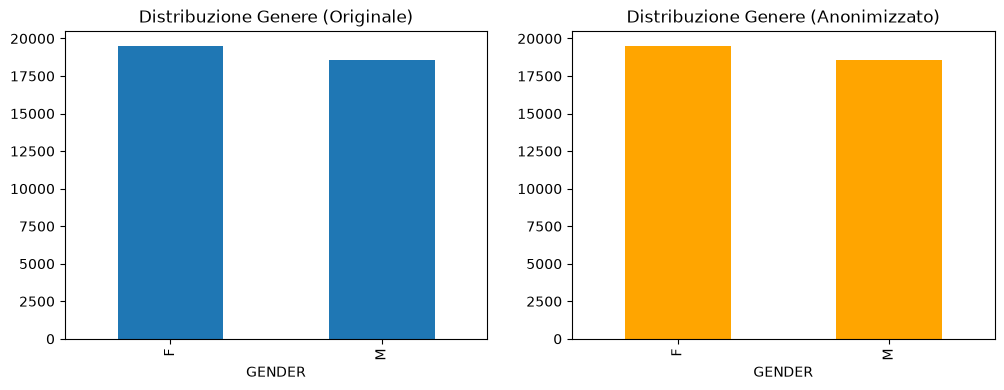

In [73]:
# Grafico di confronto
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

df_raw_merged['GENDER'].value_counts().plot(kind='bar', ax=ax[0], title="Distribuzione Genere (Originale)")
df_final_secure['GENDER'].value_counts().plot(kind='bar', ax=ax[1], title="Distribuzione Genere (Anonimizzato)", color='orange')

plt.show()

In [74]:
# FASE 4: Simulazione Rischio di Re-identificazione

# 1. Calcoliamo il Rischio nel Dataset Originale "In Chiaro"
quasi_id_raw = ['AGE', 'GENDER', 'ZIP']
rischio_raw = df_raw_merged.groupby(quasi_id_raw).size().reset_index(name='Count')

pazienti_unici_raw = len(rischio_raw[rischio_raw['Count'] == 1])
totale_pazienti = len(df_raw_merged)
prob_reid_raw = pazienti_unici_raw / totale_pazienti

print("=== SCENARIO 1: RISCHIO NEL DATASET IN CHIARO ===")
print(f"Pazienti completamente unici e vulnerabili (k=1): {pazienti_unici_raw} su {totale_pazienti}")
print(f"Probabilità globale di re-identificazione certa: {prob_reid_raw:.2%}\n")

# 2. Calcoliamo il Rischio nel Dataset Anonimizzato
# Usiamo i valori generati dalla pipeline ufficiale (k_val e classi_rischio)
pazienti_unici_anon = len(classi_rischio[classi_rischio['Count'] == 1])
rischio_massimo_anon = 1 / k_val if k_val > 0 else 1.0

print("=== SCENARIO 2: RISCHIO NEL DATASET ANONIMIZZATO ===")
print(f"Pazienti completamente unici e vulnerabili (k=1): {pazienti_unici_anon}")
print(f"Livello k-anonymity minimo garantito: k={k_val}")
print(f"Rischio MASSIMO di re-identificazione per il paziente più esposto: {rischio_massimo_anon:.2%}")
print(f"(Nota: Nel dataset in chiaro il rischio per i pazienti più esposti era del 100%)")

=== SCENARIO 1: RISCHIO NEL DATASET IN CHIARO ===
Pazienti completamente unici e vulnerabili (k=1): 7 su 38094
Probabilità globale di re-identificazione certa: 0.02%

=== SCENARIO 2: RISCHIO NEL DATASET ANONIMIZZATO ===
Pazienti completamente unici e vulnerabili (k=1): 0
Livello k-anonymity minimo garantito: k=5
Rischio MASSIMO di re-identificazione per il paziente più esposto: 20.00%
(Nota: Nel dataset in chiaro il rischio per i pazienti più esposti era del 100%)


In [75]:
import pandas as pd # <--- LA RIGA CHE RISOLVE L'ERRORE


# Creiamo una funzione che valuta il rischio e applica le linee guida
def valuta_rischio_e_policy(df_anon, nome_scenario):
    # Calcoliamo k minimo
    quasi_identifiers = ['AGE_GROUP', 'GENDER', 'ZIP_GROUP']
    k_counts = df_anon.groupby(quasi_identifiers).size()
    k_min = k_counts.min()
    
    # Rischio massimo per l'individuo più esposto
    rischio_max = (1 / k_min) if k_min > 0 else 1.0
    
    print(f"► {nome_scenario}")
    print(f"   Livello k-anonymity garantito: k = {k_min}")
    print(f"   Rischio massimo di re-identificazione: {rischio_max:.2%}")
    
    # LINEE GUIDA DI RILASCIO (Soglia del 20%)
    soglia_sicurezza = 0.20 
    if rischio_max <= soglia_sicurezza:
        print("   ESITO POLICY: CONFORME. Il dataset può essere rilasciato.\n")
    else:
        print("   ESITO POLICY: NON CONFORME! Rischio troppo alto. Aumentare generalizzazione.\n")

print("=== TEST IMPATTO GENERALIZZAZIONI SUL RISCHIO ===\n")

# Assicuriamoci di usare i dati originali grezzi
df_raw = pd.read_csv('patients.csv')

# Scenario 1: Bassa Privacy (Fasce 10 anni, CAP 3 cifre)
df_bassa = pipeline_anonimizzazione(df_raw, fascia_eta=10, cifre_cap=3)
valuta_rischio_e_policy(df_bassa, "SCENARIO 1: Bassa Privacy (Elevata Utilità)")

# Scenario 2: Equilibrata (Fasce 20 anni, CAP 2 cifre) - Il nostro target
df_media = pipeline_anonimizzazione(df_raw, fascia_eta=20, cifre_cap=2)
valuta_rischio_e_policy(df_media, "SCENARIO 2: Equilibrata (Compromesso Ottimale)")

# Scenario 3: Alta Privacy (Fasce 50 anni, CAP 1 cifra)
df_alta = pipeline_anonimizzazione(df_raw, fascia_eta=50, cifre_cap=1)
valuta_rischio_e_policy(df_alta, "SCENARIO 3: Alta Privacy (Bassa Utilità)")

=== TEST IMPATTO GENERALIZZAZIONI SUL RISCHIO ===

► SCENARIO 1: Bassa Privacy (Elevata Utilità)
   Livello k-anonymity garantito: k = 1
   Rischio massimo di re-identificazione: 100.00%
   ESITO POLICY: NON CONFORME! Rischio troppo alto. Aumentare generalizzazione.

► SCENARIO 2: Equilibrata (Compromesso Ottimale)
   Livello k-anonymity garantito: k = 5
   Rischio massimo di re-identificazione: 20.00%
   ESITO POLICY: CONFORME. Il dataset può essere rilasciato.

► SCENARIO 3: Alta Privacy (Bassa Utilità)
   Livello k-anonymity garantito: k = 35
   Rischio massimo di re-identificazione: 2.86%
   ESITO POLICY: CONFORME. Il dataset può essere rilasciato.

